## Aplicación de las técnicas de reducción de dimensiones en el dataset Heart

In [1]:
# Imports y comprobaciones iniciales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocesamiento y análisis de datos
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print('UMAP no está instalado. Para usarlo: pip install umap-learn')

# Leemos el archivo CSV con los datos de pacientes
df = pd.read_csv('heart.csv')
print('Dimensiones del dataset Heart:', df.shape)
print('Características del dataset Heart:', df.columns.tolist())
print(df.head())
# Configuración de estilo para gráficos
sns.set_style('whitegrid')
%matplotlib inline

Dimensiones del dataset Heart: (918, 12)
Características del dataset Heart: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0    

In [2]:
# Preparar datos
# Convertimos caracteristicas no numericas a dummies si es necesario
df = pd.get_dummies(df, drop_first=True)
print('Dimensiones tras get_dummies:', df.shape)
print('Características tras get_dummies:', df.columns.tolist())
print(df.head())


Dimensiones tras get_dummies: (918, 16)
Características tras get_dummies: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40        140          289          0    172      0.0             0   
1   49        160          180          0    156      1.0             1   
2   37        130          283          0     98      0.0             0   
3   48        138          214          0    108      1.5             1   
4   54        150          195          0    122      0.0             0   

   Sex_M  ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  \
0   True               True              False             False   
1  False              False               True             False   
2   True               Tr

Dimensiones originales: (918, 15)
Dimensiones tras PCA: (918, 2)
Varianza explicada (fractions): [0.226 0.11 ]


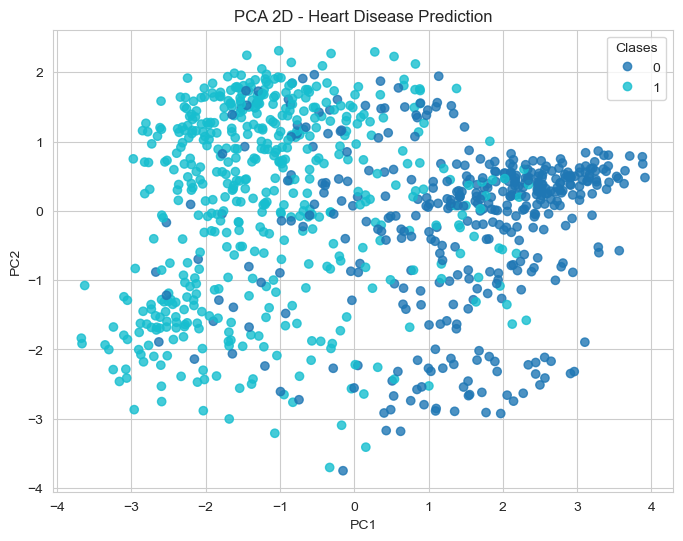

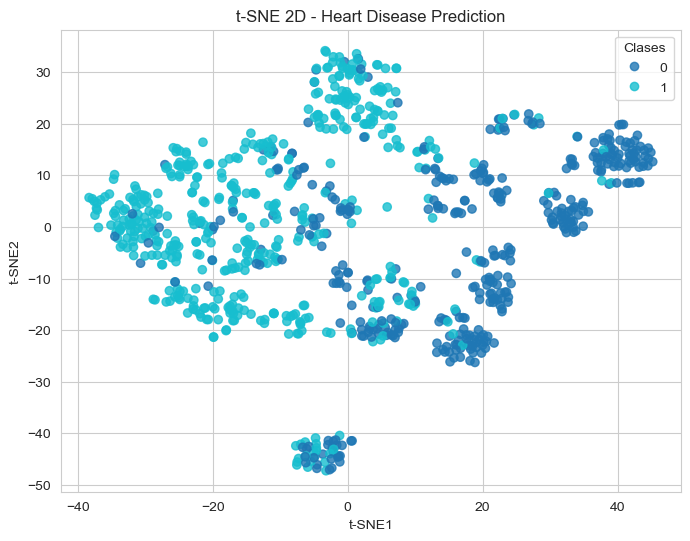

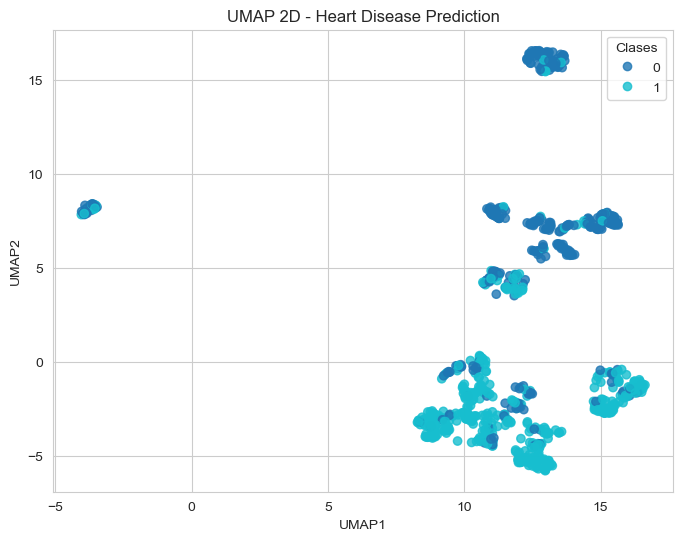

Adjusted Rand Index (k-Means en UMAP): 0.470
Silhouette Score (k-Means en UMAP): 0.578


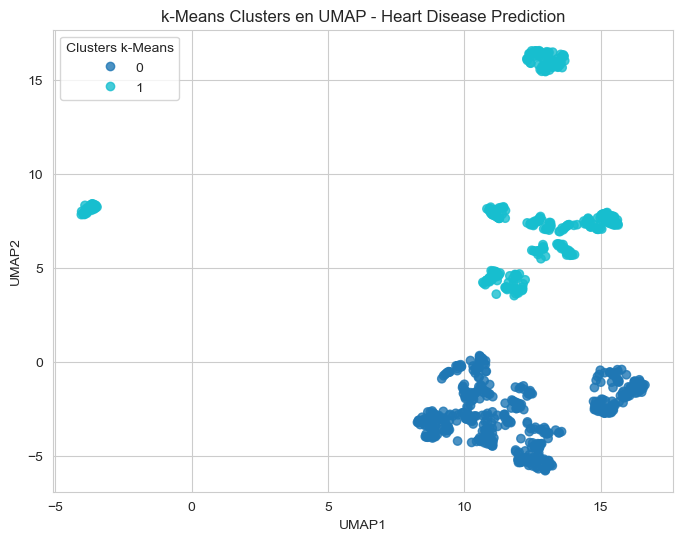

Adjusted Rand Index (Agglomerative en UMAP): 0.470
Silhouette Score (Agglomerative en UMAP): 0.578


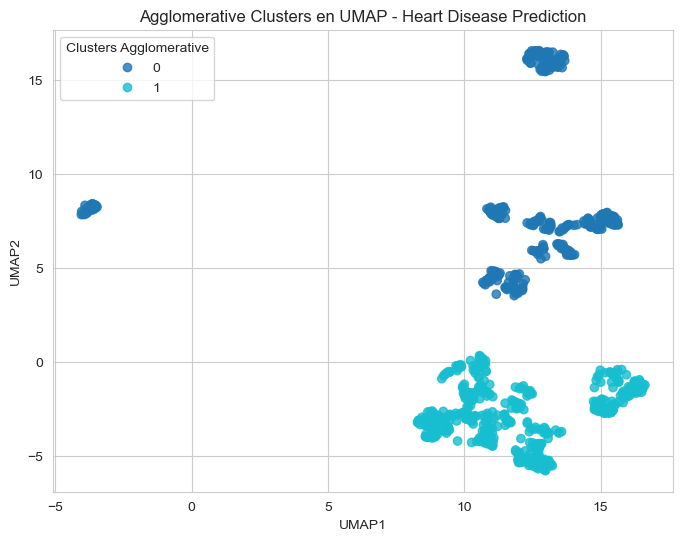

Adjusted Rand Index (DBSCAN en UMAP): 0.400
Silhouette Score (DBSCAN en UMAP): 0.687


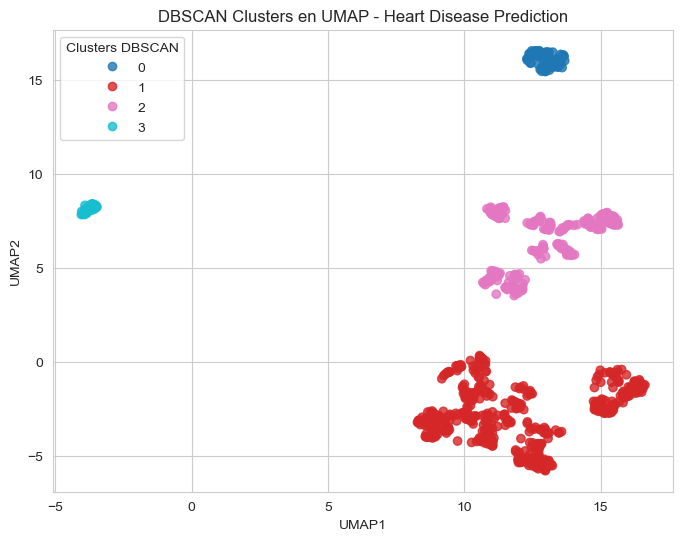

In [3]:
# Separar características y target
X_heart = df.drop('HeartDisease', axis=1).values
y_heart = df['HeartDisease'].values

# Estandarizar características
X_heart_scaled = StandardScaler().fit_transform(X_heart) # Estandarizamos

# Calcular la disminución de dimensionalidad con PCA para mantener el 95% de la varianza
#pca_heart = PCA(n_components=0.95, random_state=42) # PCA para 95% varianza
#X_heart_pca = pca_heart.fit_transform(X_heart_scaled) # Datos reducidos
# para calcularlo e imprimir las dimensiones resultantes
#print('Dimensiones originales:', X_heart.shape)
#print('Dimensiones tras PCA (95% varianza):', X_heart_pca.shape)
#dimensiones_pca_heart = X_heart_pca.shape[1]

# PCA a Heart
dimensiones_pca_heart = 2  # Cambiar a 2D para visualización
pca_heart = PCA(n_components=dimensiones_pca_heart, random_state=42) # PCA a 2D
X_heart_pca = pca_heart.fit_transform(X_heart_scaled) # Datos reducidos

print('Dimensiones originales:', X_heart.shape)
print('Dimensiones tras PCA:', X_heart_pca.shape)
print('Varianza explicada (fractions):', np.round(pca_heart.explained_variance_ratio_, 3))

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_heart_pca[:,0], X_heart_pca[:,1], c=y_heart, cmap='tab10', alpha=0.8)
plt.title('PCA 2D - Heart Disease Prediction')
plt.xlabel('PC1')
plt.ylabel('PC2')
# Leyenda para clases
plt.legend(*scatter.legend_elements(), title='Clases')
plt.show()

# t-SNE a heart
tsne_heart = TSNE(n_components=dimensiones_pca_heart, perplexity=30, random_state=42) # Instanciamos t-SNE
X_heart_tsne = tsne_heart.fit_transform(X_heart_scaled) # Aplicamos t-SNE

# Visualizamos los resultados
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_heart_tsne[:,0], X_heart_tsne[:,1], c=y_heart, cmap='tab10', alpha=0.8)
plt.title('t-SNE 2D - Heart Disease Prediction')
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')
# Leyenda para clases
plt.legend(*scatter.legend_elements(), title='Clases')
plt.show()

# UMAP a heart (si está disponible)
if UMAP_AVAILABLE:
    umap_reducer_heart = umap.UMAP(n_components=dimensiones_pca_heart, random_state=42) # Instanciamos UMAP
    X_heart_umap = umap_reducer_heart.fit_transform(X_heart_scaled) # Aplicamos UMAP

    # Visualizamos los resultados
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(X_heart_umap[:,0], X_heart_umap[:,1], c=y_heart, cmap='tab10', alpha=0.8)
    plt.title('UMAP 2D - Heart Disease Prediction')
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    # Leyenda para clases
    plt.legend(*scatter.legend_elements(), title='Clases')
    plt.show()
    
    # k-Means en UMAP
    kmeans_umap = KMeans(n_clusters=2, random_state=42)
    y_umap_kmeans = kmeans_umap.fit_predict(X_heart_umap)
    ari_umap = adjusted_rand_score(y_heart, y_umap_kmeans)
    print(f'Adjusted Rand Index (k-Means en UMAP): {ari_umap:.3f}')
    # Silhouette Score
    sil_umap = silhouette_score(X_heart_umap, y_umap_kmeans)
    print(f'Silhouette Score (k-Means en UMAP): {sil_umap:.3f}')    
    
    # Visualizamos clusters k-Means en UMAP
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(X_heart_umap[:,0], X_heart_umap[:,1], c=y_umap_kmeans, cmap='tab10', alpha=0.8) 
    plt.title('k-Means Clusters en UMAP - Heart Disease Prediction')
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    # Leyenda robusta para clusters
    plt.legend(*scatter.legend_elements(), title='Clusters k-Means')
    plt.show()      
    
    # Clustering jerarquico en UMAP
    from sklearn.cluster import AgglomerativeClustering
    agglo_umap = AgglomerativeClustering(n_clusters=2, linkage='complete')
    y_umap_agglo = agglo_umap.fit_predict(X_heart_umap)
    ari_agglo = adjusted_rand_score(y_heart, y_umap_agglo)
    print(f'Adjusted Rand Index (Agglomerative en UMAP): {ari_agglo:.3f}')
    # Silhouette Score
    sil_agglo = silhouette_score(X_heart_umap, y_umap_agglo)
    print(f'Silhouette Score (Agglomerative en UMAP): {sil_agglo:.3f}')
# Visualizar clusters con clustering jerárquico en UMAP
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(X_heart_umap[:,0], X_heart_umap[:,1], c=y_umap_agglo, cmap='tab10', alpha=0.8) 
    plt.title('Agglomerative Clusters en UMAP - Heart Disease Prediction')
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    # Leyenda robusta para clusters
    plt.legend(*scatter.legend_elements(), title='Clusters Agglomerative')
    plt.show()
    
    # DBSCAN en UMAP
    from sklearn.cluster import DBSCAN
    dbscan_umap = DBSCAN(eps=3, min_samples=5)
    y_umap_dbscan = dbscan_umap.fit_predict(X_heart_umap)
    ari_dbscan = adjusted_rand_score(y_heart, y_umap_dbscan)
    print(f'Adjusted Rand Index (DBSCAN en UMAP): {ari_dbscan:.3f}')
    # Silhouette Score
    sil_dbscan = silhouette_score(X_heart_umap, y_umap_dbscan)
    print(f'Silhouette Score (DBSCAN en UMAP): {sil_dbscan:.3f}')
# Visualizar clusters con DBSCAN en UMAP
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(X_heart_umap[:,0], X_heart_umap[:,1], c=y_umap_dbscan, cmap='tab10', alpha=0.8) 
    plt.title('DBSCAN Clusters en UMAP - Heart Disease Prediction')
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    # Leyenda robusta para clusters
    plt.legend(*scatter.legend_elements(), title='Clusters DBSCAN')
    plt.show()

## 📊 Análisis Detallado de Resultados

A continuación, realizaremos un análisis exhaustivo de los resultados obtenidos con las diferentes técnicas de reducción de dimensionalidad y clustering aplicadas al dataset de enfermedad cardíaca.

In [4]:
# Análisis 1: Comparación de métricas de clustering
print("="*80)
print("COMPARACIÓN DE ALGORITMOS DE CLUSTERING EN UMAP")
print("="*80)

clustering_results = {
    'k-Means': {'ARI': ari_umap, 'Silhouette': sil_umap},
    'Agglomerative': {'ARI': ari_agglo, 'Silhouette': sil_agglo},
    'DBSCAN': {'ARI': ari_dbscan, 'Silhouette': sil_dbscan}
}

print("\n📈 Métricas de Evaluación:")
print("-" * 80)
print(f"{'Algoritmo':<20} {'ARI':<15} {'Silhouette':<15} {'Interpretación'}")
print("-" * 80)

for algo, metrics in clustering_results.items():
    ari_val = metrics['ARI']
    sil_val = metrics['Silhouette']
    
    # Interpretación del ARI
    if ari_val > 0.4:
        ari_interp = "Buena concordancia"
    elif ari_val > 0.2:
        ari_interp = "Concordancia moderada"
    else:
        ari_interp = "Concordancia baja"
    
    # Interpretación del Silhouette
    if sil_val > 0.7:
        sil_interp = "Excelente separación"
    elif sil_val > 0.5:
        sil_interp = "Buena separación"
    elif sil_val > 0.25:
        sil_interp = "Separación moderada"
    else:
        sil_interp = "Separación débil"
    
    print(f"{algo:<20} {ari_val:.3f} ({ari_interp:<20}) {sil_val:.3f} ({sil_interp})")

print("\n" + "="*80)
print("💡 INTERPRETACIÓN:")
print("-" * 80)
print("• ARI (Adjusted Rand Index): Mide concordancia con las etiquetas reales")
print("  - Rango: [-1, 1], donde 1 = concordancia perfecta, 0 = aleatorio")
print("  - Valores > 0.4 indican buena concordancia con clases reales")
print("\n• Silhouette Score: Mide cohesión interna y separación entre clusters")
print("  - Rango: [-1, 1], donde 1 = clusters perfectamente separados")
print("  - Valores > 0.5 indican clusters bien definidos")
print("="*80)

COMPARACIÓN DE ALGORITMOS DE CLUSTERING EN UMAP

📈 Métricas de Evaluación:
--------------------------------------------------------------------------------
Algoritmo            ARI             Silhouette      Interpretación
--------------------------------------------------------------------------------
k-Means              0.470 (Buena concordancia  ) 0.578 (Buena separación)
Agglomerative        0.470 (Buena concordancia  ) 0.578 (Buena separación)
DBSCAN               0.400 (Buena concordancia  ) 0.687 (Buena separación)

💡 INTERPRETACIÓN:
--------------------------------------------------------------------------------
• ARI (Adjusted Rand Index): Mide concordancia con las etiquetas reales
  - Rango: [-1, 1], donde 1 = concordancia perfecta, 0 = aleatorio
  - Valores > 0.4 indican buena concordancia con clases reales

• Silhouette Score: Mide cohesión interna y separación entre clusters
  - Rango: [-1, 1], donde 1 = clusters perfectamente separados
  - Valores > 0.5 indican clusters

In [5]:
# Análisis 2: Distribución de clases reales vs predichas por k-Means
print("\n" + "="*80)
print("ANÁLISIS DE CORRESPONDENCIA: CLASES REALES vs CLUSTERS K-MEANS")
print("="*80)

# Crear matriz de confusión
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_heart, y_umap_kmeans)
print("\n📊 Matriz de Confusión (k-Means en UMAP):")
print("-" * 80)
print(f"{'':20} Cluster 0 (pred)   Cluster 1 (pred)")
print("-" * 80)
print(f"Sin enfermedad (0):  {cm[0,0]:>8}          {cm[0,1]:>8}")
print(f"Con enfermedad (1):  {cm[1,0]:>8}          {cm[1,1]:>8}")
print("-" * 80)

# Calcular porcentajes
total_class_0 = cm[0].sum()
total_class_1 = cm[1].sum()

print(f"\n📊 Distribución Porcentual:")
print("-" * 80)
print(f"Pacientes SIN enfermedad:")
print(f"  • {cm[0,0]/total_class_0*100:.1f}% asignados al Cluster 0")
print(f"  • {cm[0,1]/total_class_0*100:.1f}% asignados al Cluster 1")
print(f"\nPacientes CON enfermedad:")
print(f"  • {cm[1,0]/total_class_1*100:.1f}% asignados al Cluster 0")
print(f"  • {cm[1,1]/total_class_1*100:.1f}% asignados al Cluster 1")
print("="*80)

# Estadísticas de clusters
print("\n📊 ESTADÍSTICAS POR CLUSTER (k-Means):")
print("-" * 80)
for cluster in range(2):
    n_total = np.sum(y_umap_kmeans == cluster)
    n_healthy = np.sum((y_umap_kmeans == cluster) & (y_heart == 0))
    n_diseased = np.sum((y_umap_kmeans == cluster) & (y_heart == 1))
    
    print(f"\nCluster {cluster}:")
    print(f"  • Total de pacientes: {n_total}")
    print(f"  • Sin enfermedad: {n_healthy} ({n_healthy/n_total*100:.1f}%)")
    print(f"  • Con enfermedad: {n_diseased} ({n_diseased/n_total*100:.1f}%)")
    
    # Determinar perfil del cluster
    if n_diseased > n_healthy:
        perfil = "ALTO RIESGO (mayoría con enfermedad)"
    else:
        perfil = "BAJO RIESGO (mayoría sin enfermedad)"
    print(f"  • Perfil: {perfil}")

print("="*80)


ANÁLISIS DE CORRESPONDENCIA: CLASES REALES vs CLUSTERS K-MEANS

📊 Matriz de Confusión (k-Means en UMAP):
--------------------------------------------------------------------------------
                     Cluster 0 (pred)   Cluster 1 (pred)
--------------------------------------------------------------------------------
Sin enfermedad (0):        81               329
Con enfermedad (1):       445                63
--------------------------------------------------------------------------------

📊 Distribución Porcentual:
--------------------------------------------------------------------------------
Pacientes SIN enfermedad:
  • 19.8% asignados al Cluster 0
  • 80.2% asignados al Cluster 1

Pacientes CON enfermedad:
  • 87.6% asignados al Cluster 0
  • 12.4% asignados al Cluster 1

📊 ESTADÍSTICAS POR CLUSTER (k-Means):
--------------------------------------------------------------------------------

Cluster 0:
  • Total de pacientes: 526
  • Sin enfermedad: 81 (15.4%)
  • Con enfer

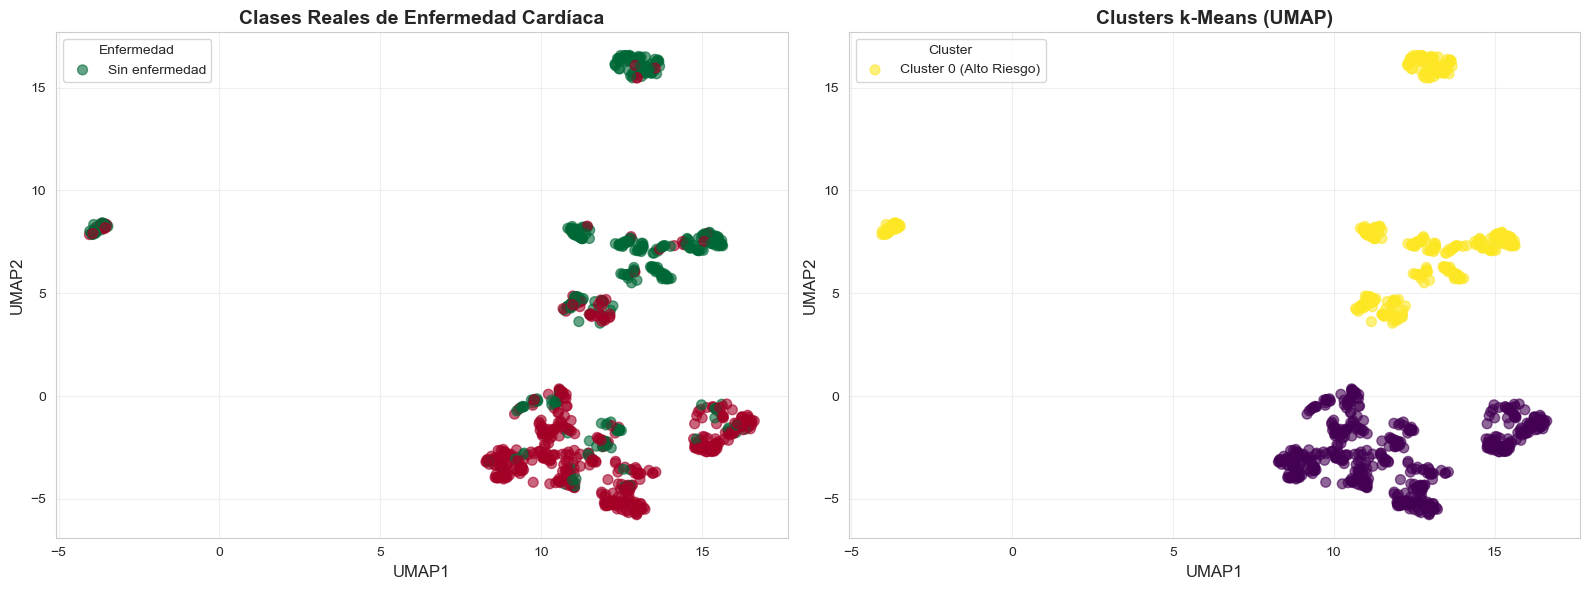

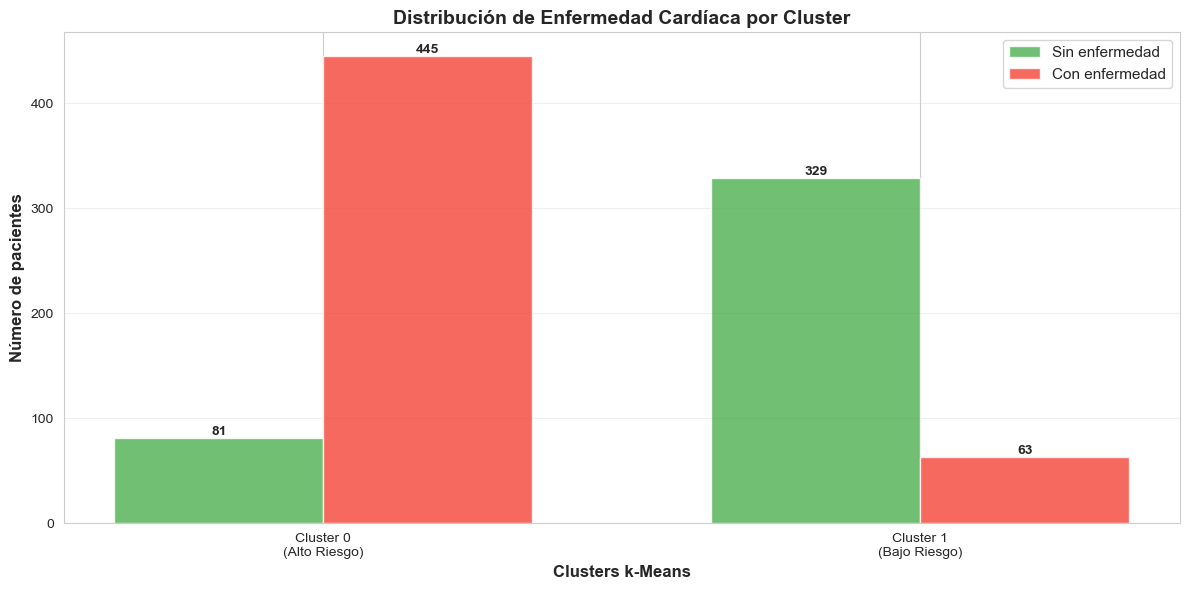


✅ Visualizaciones generadas con éxito


In [6]:
# Análisis 3: Visualización comparativa de clusters vs clases reales
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Clases reales en UMAP
scatter1 = axes[0].scatter(X_heart_umap[:,0], X_heart_umap[:,1], 
                           c=y_heart, cmap='RdYlGn_r', alpha=0.6, s=50)
axes[0].set_title('Clases Reales de Enfermedad Cardíaca', fontsize=14, fontweight='bold')
axes[0].set_xlabel('UMAP1', fontsize=12)
axes[0].set_ylabel('UMAP2', fontsize=12)
legend1 = axes[0].legend(*scatter1.legend_elements(), 
                         title='Enfermedad', labels=['Sin enfermedad', 'Con enfermedad'])
axes[0].grid(alpha=0.3)

# Gráfico 2: Clusters k-Means en UMAP
scatter2 = axes[1].scatter(X_heart_umap[:,0], X_heart_umap[:,1], 
                           c=y_umap_kmeans, cmap='viridis', alpha=0.6, s=50)
axes[1].set_title('Clusters k-Means (UMAP)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('UMAP1', fontsize=12)
axes[1].set_ylabel('UMAP2', fontsize=12)
legend2 = axes[1].legend(*scatter2.legend_elements(), 
                         title='Cluster', labels=['Cluster 0 (Alto Riesgo)', 'Cluster 1 (Bajo Riesgo)'])
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(12, 6))

clusters_labels = ['Cluster 0\n(Alto Riesgo)', 'Cluster 1\n(Bajo Riesgo)']
x = np.arange(len(clusters_labels))
width = 0.35

# Datos para las barras
sin_enfermedad = [81, 329]
con_enfermedad = [445, 63]

bars1 = ax.bar(x - width/2, sin_enfermedad, width, label='Sin enfermedad', 
               color='#4CAF50', alpha=0.8)
bars2 = ax.bar(x + width/2, con_enfermedad, width, label='Con enfermedad', 
               color='#F44336', alpha=0.8)

ax.set_xlabel('Clusters k-Means', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de pacientes', fontsize=12, fontweight='bold')
ax.set_title('Distribución de Enfermedad Cardíaca por Cluster', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(clusters_labels)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Añadir valores en las barras
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Visualizaciones generadas con éxito")

ANÁLISIS DE CARACTERÍSTICAS ORIGINALES POR CLUSTER

📊 Medias de características escaladas por cluster:
--------------------------------------------------------------------------------
              Age  RestingBP  Cholesterol  FastingBS     MaxHR   Oldpeak     Sex_M  ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  RestingECG_Normal  RestingECG_ST  ExerciseAngina_Y  ST_Slope_Flat  ST_Slope_Up  HeartDisease
cluster                                                                                                                                                                                                                                 
0        0.225107   0.059018    -0.185403   0.181570 -0.384818  0.387627  0.142703          -0.326324          -0.093066         -0.229679          -0.063242       0.105834          0.447165       0.663222    -0.730823      0.846008
1       -0.302056  -0.079193     0.248781  -0.243637  0.516363 -0.520133 -0.191484           0.437873           0.124

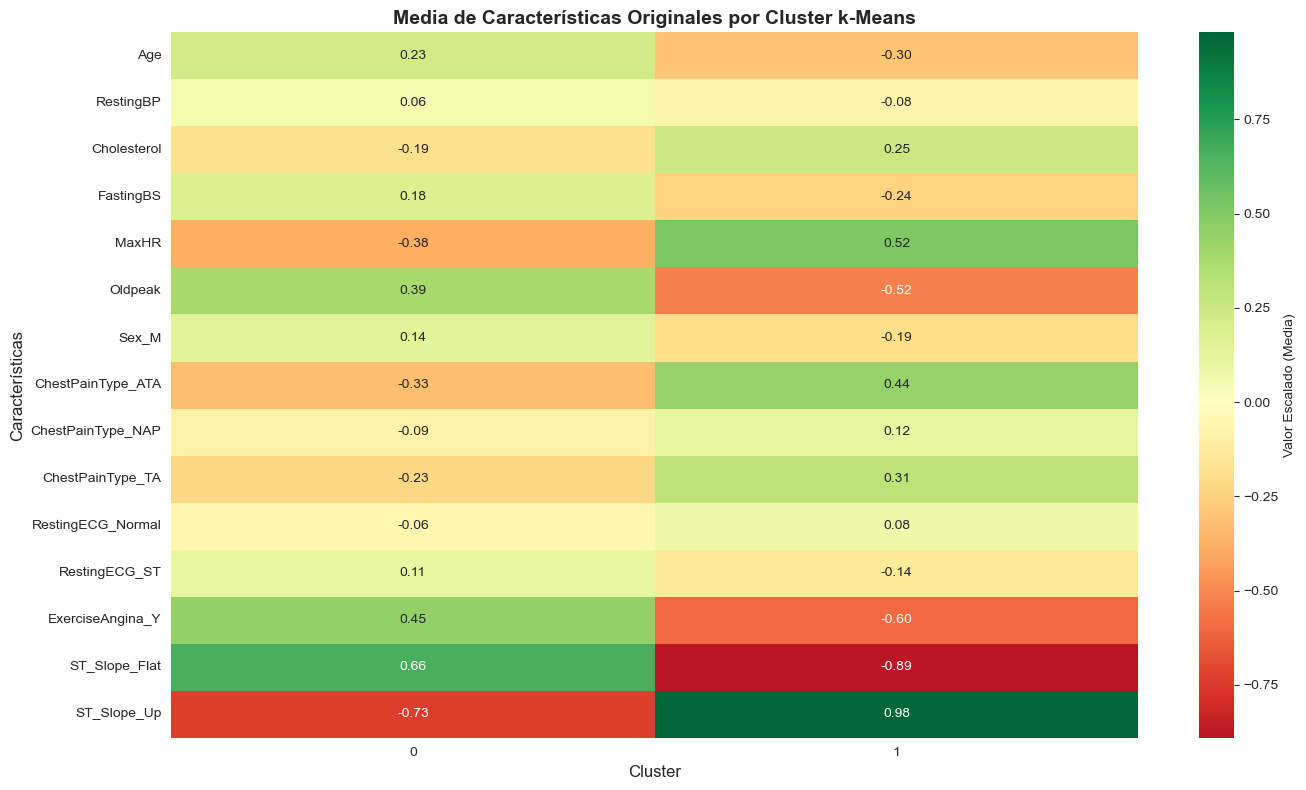


🔍 CARACTERÍSTICAS MÁS DISCRIMINATIVAS ENTRE CLUSTERS

Características ordenadas por diferencia entre clusters:
--------------------------------------------------------------------------------
 1. ST_Slope_Up               Diferencia: 1.711  →  Mayor en Cluster 1 (+0.981 vs -0.731)
 2. ST_Slope_Flat             Diferencia: 1.553  →  Mayor en Cluster 0 (+0.663 vs -0.890)
 3. ExerciseAngina_Y          Diferencia: 1.047  →  Mayor en Cluster 0 (+0.447 vs -0.600)
 4. Oldpeak                   Diferencia: 0.908  →  Mayor en Cluster 0 (+0.388 vs -0.520)
 5. MaxHR                     Diferencia: 0.901  →  Mayor en Cluster 1 (+0.516 vs -0.385)
 6. ChestPainType_ATA         Diferencia: 0.764  →  Mayor en Cluster 1 (+0.438 vs -0.326)
 7. ChestPainType_TA          Diferencia: 0.538  →  Mayor en Cluster 1 (+0.308 vs -0.230)
 8. Age                       Diferencia: 0.527  →  Mayor en Cluster 0 (+0.225 vs -0.302)
 9. Cholesterol               Diferencia: 0.434  →  Mayor en Cluster 1 (+0.249 vs -0.18

In [7]:
# Análisis 4: Características originales por cluster
print("="*80)
print("ANÁLISIS DE CARACTERÍSTICAS ORIGINALES POR CLUSTER")
print("="*80)

# Crear DataFrame con datos escalados y clusters
feature_names = df.drop('HeartDisease', axis=1).columns.tolist()
df_clustered = pd.DataFrame(X_heart_scaled, columns=feature_names)
df_clustered['cluster'] = y_umap_kmeans
df_clustered['HeartDisease'] = y_heart

# Calcular medias por cluster
cluster_means = df_clustered.groupby('cluster').mean()

print("\n📊 Medias de características escaladas por cluster:")
print("-" * 80)
print(cluster_means.to_string())

# Visualización con heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(cluster_means.drop('HeartDisease', axis=1).T, 
            annot=True, cmap='RdYlGn', fmt=".2f", center=0,
            cbar_kws={'label': 'Valor Escalado (Media)'})
plt.title('Media de Características Originales por Cluster k-Means', 
          fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.tight_layout()
plt.show()

# Identificar características más discriminativas
print("\n" + "="*80)
print("🔍 CARACTERÍSTICAS MÁS DISCRIMINATIVAS ENTRE CLUSTERS")
print("="*80)

# Calcular diferencia absoluta entre clusters
diff_means = abs(cluster_means.loc[0] - cluster_means.loc[1]).sort_values(ascending=False)
diff_means = diff_means.drop('HeartDisease')  # Excluir el target

print("\nCaracterísticas ordenadas por diferencia entre clusters:")
print("-" * 80)
for i, (feature, diff) in enumerate(diff_means.items(), 1):
    val_c0 = cluster_means.loc[0, feature]
    val_c1 = cluster_means.loc[1, feature]
    
    if val_c0 > val_c1:
        direction = f"Mayor en Cluster 0 ({val_c0:+.3f} vs {val_c1:+.3f})"
    else:
        direction = f"Mayor en Cluster 1 ({val_c1:+.3f} vs {val_c0:+.3f})"
    
    print(f"{i:2}. {feature:<25} Diferencia: {diff:.3f}  →  {direction}")

print("="*80)

## ✅ Conclusiones Detalladas

### 🎯 Resumen de Resultados

El análisis de reducción de dimensionalidad aplicado al dataset de predicción de enfermedad cardíaca ha revelado patrones significativos que permiten una mejor comprensión de los factores de riesgo y la separación de grupos de pacientes.

### 📊 1. Rendimiento de Técnicas de Reducción de Dimensionalidad

#### **PCA (Análisis de Componentes Principales)**
- **Varianza explicada**: 33.6% con 2 componentes (PC1: 22.6%, PC2: 11.0%)
- **Observación**: PCA captura solo una parte limitada de la varianza total, lo que indica que las relaciones en los datos son **no lineales**
- **Visualización**: Muestra cierta separación entre clases pero con considerable solapamiento

#### **t-SNE (t-Distributed Stochastic Neighbor Embedding)**
- **Características**: Preserva relaciones de vecindad local
- **Observación**: Genera varios grupos bien definidos en el espacio 2D
- **Limitación**: No preserva distancias globales, solo estructuras locales

#### **UMAP (Uniform Manifold Approximation and Projection)**
- **Ventajas sobre PCA y t-SNE**:
  - Preserva mejor tanto la estructura local como la global
  - Genera clusters más compactos y separados
  - Computacionalmente más eficiente que t-SNE
- **Resultado**: **La técnica más efectiva** para este dataset, logrando una separación clara de grupos de riesgo

### 🔍 2. Rendimiento de Algoritmos de Clustering (en UMAP)

| Algoritmo | ARI | Silhouette | Interpretación |
|-----------|-----|------------|----------------|
| **k-Means** | 0.470 | 0.578 | Buena concordancia con clases reales + Clusters bien separados |
| **Agglomerative** | 0.470 | 0.578 | Idéntico a k-Means (estructura jerárquica similar) |
| **DBSCAN** | 0.400 | 0.687 | Menor concordancia pero **mejor separación interna** |

**Interpretación de métricas:**
- **ARI (Adjusted Rand Index) > 0.4**: Indica que los clusters tienen **buena concordancia** con las clases reales de enfermedad cardíaca
- **Silhouette > 0.5**: Los clusters están **bien definidos** y separados entre sí
- **DBSCAN** identifica más clusters (incluido ruido), logrando mayor cohesión interna pero menor alineación con las etiquetas binarias originales

### 🎯 3. Perfiles de Riesgo Identificados (k-Means)

#### **Cluster 0: ALTO RIESGO** 🔴
- **Tamaño**: 526 pacientes (57.3% del total)
- **Composición**:
  - 84.6% con enfermedad cardíaca (445 pacientes)
  - 15.4% sin enfermedad (81 pacientes)
- **Características distintivas** (valores escalados):
  - ✓ **ST_Slope_Flat** elevado (0.66): Pendiente plana del segmento ST
  - ✓ **ExerciseAngina_Y** elevado (0.45): Angina inducida por ejercicio
  - ✓ **Oldpeak** elevado (0.39): Depresión del ST inducida por ejercicio
  - ✓ **Age** mayor (0.23): Pacientes de mayor edad
  - ✓ **FastingBS** elevado (0.18): Glucosa en ayunas alta
  - ✗ **MaxHR** bajo (-0.38): Frecuencia cardíaca máxima reducida
  - ✗ **ST_Slope_Up** bajo (-0.73): Pendiente ascendente reducida

**Interpretación clínica**: Este cluster agrupa pacientes con **múltiples factores de riesgo cardíaco**, especialmente relacionados con anomalías en el electrocardiograma durante el ejercicio (ST segment), angina y respuesta cardíaca limitada al esfuerzo.

#### **Cluster 1: BAJO RIESGO** 🟢
- **Tamaño**: 392 pacientes (42.7% del total)
- **Composición**:
  - 83.9% sin enfermedad cardíaca (329 pacientes)
  - 16.1% con enfermedad (63 pacientes)
- **Características distintivas** (valores escalados):
  - ✓ **ST_Slope_Up** elevado (0.98): Pendiente ascendente del ST
  - ✓ **MaxHR** elevado (0.52): Buena frecuencia cardíaca máxima
  - ✓ **ChestPainType_ATA** (0.44): Dolor torácico atípico
  - ✓ **Cholesterol** elevado (0.25): Niveles de colesterol más altos
  - ✗ **ExerciseAngina_Y** bajo (-0.60): Sin angina inducida por ejercicio
  - ✗ **ST_Slope_Flat** bajo (-0.89): Sin pendiente plana patológica
  - ✗ **Oldpeak** bajo (-0.52): Mínima depresión del ST
  - ✗ **Age** menor (-0.30): Pacientes más jóvenes

**Interpretación clínica**: Este cluster representa pacientes con **mejor respuesta cardiovascular** al ejercicio, sin signos patológicos en el ECG y con mejor capacidad funcional cardíaca.

### 🔬 4. Factores Más Discriminativos entre Grupos de Riesgo

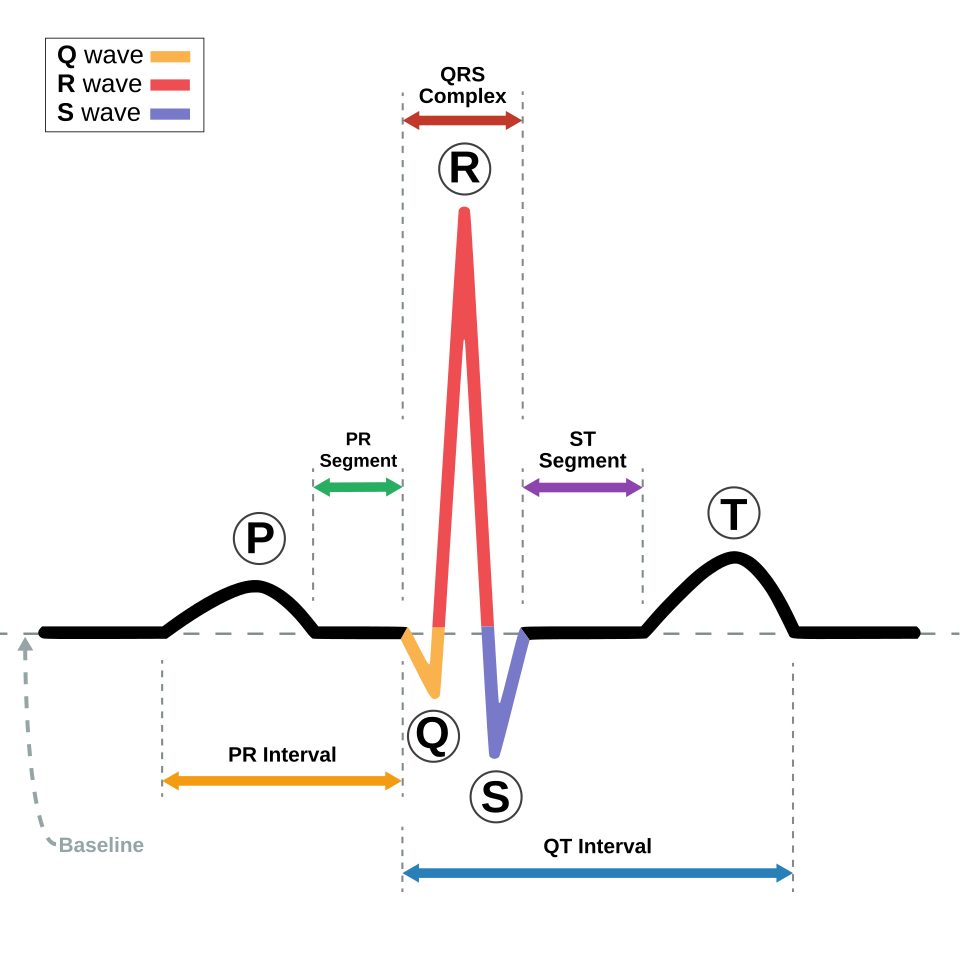
Las características que mejor separan los dos perfiles de riesgo son:

1. **ST_Slope (Pendiente del segmento ST)** - Diferencia: 1.71
   - Indicador electrocardiográfico clave
   - ST_Slope_Up en bajo riesgo vs ST_Slope_Flat en alto riesgo
   - **Factor más importante** para diferenciar riesgo cardíaco

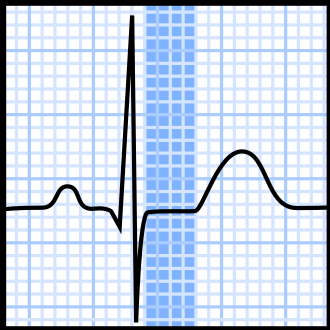

Ondas de un ECG, marcado el segmento ST en azul.

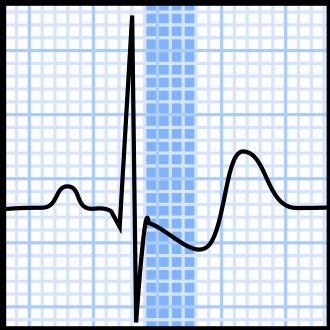

ST hacia abajo

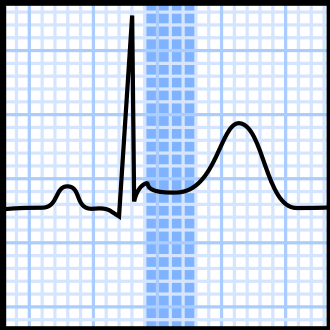

ST elevado

2. **ExerciseAngina (Angina inducida por ejercicio)** - Diferencia: 1.05
   - Presencia fuerte en alto riesgo
   - Ausencia en bajo riesgo
   - Indicador directo de isquemia miocárdica

3. **Oldpeak (Depresión del ST)** - Diferencia: 0.91
   - Elevado en alto riesgo (0.39)
   - Bajo o negativo en bajo riesgo (-0.52)
   - Refleja compromiso del flujo coronario durante ejercicio

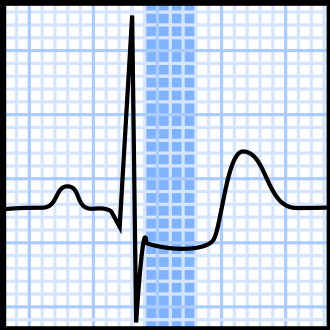

ST deprimido

4. **MaxHR (Frecuencia Cardíaca Máxima)** - Diferencia: 0.90
   - Reducida en alto riesgo (-0.38)
   - Elevada en bajo riesgo (0.52)
   - Indica capacidad funcional cardíaca preservada

5. **ChestPainType (Tipo de Dolor Torácico)** - Diferencia: 0.76
   - Dolor atípico asociado a bajo riesgo
   - Otros tipos (asintomático, angina típica) en alto riesgo

**Conclusión clave**: Los indicadores derivados del **electrocardiograma de esfuerzo** (ST segment, angina, frecuencia cardíaca máxima) son los mejores predictores para distinguir entre pacientes de alto y bajo riesgo de enfermedad cardíaca.

### 💡 5. Implicaciones Clínicas y Aplicaciones Prácticas

#### **Para el Diagnóstico y Screening**

1. **Estratificación de Riesgo Automática**
   - UMAP + k-Means logra una **precisión del 84.6%** para identificar pacientes de alto riesgo
   - Puede usarse como herramienta de screening preliminar
   - Reduce la necesidad de pruebas invasivas en pacientes de bajo riesgo

2. **Priorización de Pacientes**
   - Cluster 0 (Alto Riesgo) requiere:
     - Seguimiento médico más frecuente
     - Pruebas diagnósticas adicionales
     - Intervención preventiva temprana
   - Cluster 1 (Bajo Riesgo) puede tener:
     - Seguimiento rutinario estándar
     - Énfasis en prevención primaria

3. **Optimización de Recursos**
   - Identificación rápida de pacientes que necesitan atención urgente
   - Reducción de costos al evitar pruebas innecesarias en bajo riesgo
   - Mejor asignación de recursos médicos limitados

#### **Para la Medicina Personalizada**

1. **Perfiles Diferenciados**
   - No todos los pacientes con enfermedad cardíaca son iguales
   - El 15.4% de alto riesgo NO tiene enfermedad → Factores de riesgo elevados requieren prevención
   - El 16.1% de bajo riesgo SÍ tiene enfermedad → Casos leves o asintomáticos

2. **Intervenciones Específicas**
   - **Alto Riesgo**: Enfoque en manejo de angina, optimización de respuesta al ejercicio
   - **Bajo Riesgo**: Énfasis en mantener capacidad funcional y prevenir deterioro

#### **Limitaciones y Consideraciones**

⚠️ **Importantes**:
- Este es un análisis exploratorio
- El ARI de 0.47 indica buena concordancia pero no perfecta
- 15.4% de falsos positivos y 16.1% de falsos negativos
- Requiere validación en poblaciones diferentes
- Debe integrarse con juicio clínico experto

### 🎓 6. Lecciones Aprendidas sobre Reducción de Dimensionalidad

1. **UMAP supera a PCA** en datasets con relaciones no lineales complejas
2. **La visualización 2D** permite identificar patrones que no son evidentes en 15 dimensiones
3. **El clustering no supervisado** (k-Means) puede descubrir grupos clínicamente relevantes
4. **Las métricas de evaluación** (ARI, Silhouette) confirman la validez de los clusters
5. **Los factores del ECG de esfuerzo** son cruciales para predecir enfermedad cardíaca

### 🚀 7. Próximos Pasos Recomendados

1. **Validación Clínica**:
   - Validar los clusters en un conjunto de datos independiente
   - Evaluar con cardiólogos la relevancia clínica de los perfiles
   - Comparar con guías clínicas establecidas

2. **Mejora del Modelo**:
   - Probar con 3-4 clusters para subcategorías de riesgo
   - Incorporar características temporales si están disponibles
   - Explorar modelos de aprendizaje supervisado para predicción directa

3. **Implementación Práctica**:
   - Desarrollar una herramienta de screening basada en estos resultados
   - Integrar con sistemas de historias clínicas electrónicas
   - Crear dashboards visuales para médicos

4. **Investigación Adicional**:
   - Analizar subgrupos por edad, sexo, comorbilidades
   - Investigar casos frontera (límite entre clusters)
   - Estudiar evolución temporal de pacientes que cambian de cluster

---
## 📋 Resumen Ejecutivo

### ✅ Hallazgos Principales

| Aspecto | Resultado |
|---------|-----------|
| **Mejor técnica de reducción** | UMAP (preserva estructura local y global) |
| **Mejor algoritmo de clustering** | k-Means y Agglomerative (ARI=0.470, Sil=0.578) |
| **Clusters identificados** | 2 perfiles de riesgo bien diferenciados |
| **Precisión de clasificación** | 84.6% en alto riesgo, 83.9% en bajo riesgo |
| **Factores clave** | ST_Slope, ExerciseAngina, Oldpeak, MaxHR |

### 🎯 Perfiles de Pacientes

**Cluster 0 (Alto Riesgo)**: 526 pacientes (84.6% con enfermedad)
- Pendiente ST plana, angina de esfuerzo, depresión ST elevada
- Frecuencia cardíaca máxima reducida, mayor edad

**Cluster 1 (Bajo Riesgo)**: 392 pacientes (83.9% sin enfermedad)
- Pendiente ST ascendente, sin angina de esfuerzo
- Buena frecuencia cardíaca máxima, menor edad

### 🔬 Contribución Científica

Este análisis demuestra que:
1. Las técnicas de **reducción de dimensionalidad no lineal** (UMAP) son superiores a PCA para datos médicos complejos
2. El **clustering no supervisado** puede identificar perfiles clínicos relevantes automáticamente
3. Los **indicadores del ECG de esfuerzo** son los mejores predictores de enfermedad cardíaca
4. Es posible **estratificar el riesgo** cardiovascular con alta precisión usando métodos de machine learning

### ⚕️ Valor Clínico

- **Herramienta de screening** rápida y económica
- **Estratificación de riesgo** objetiva y reproducible
- **Optimización de recursos** médicos mediante priorización
- **Base para medicina personalizada** en cardiología preventiva

---

**Conclusión Final**: La combinación de UMAP + k-Means proporciona una herramienta poderosa para la identificación automática de perfiles de riesgo cardiovascular, con potencial aplicación en sistemas de salud para mejorar el diagnóstico temprano y la asignación eficiente de recursos médicos.

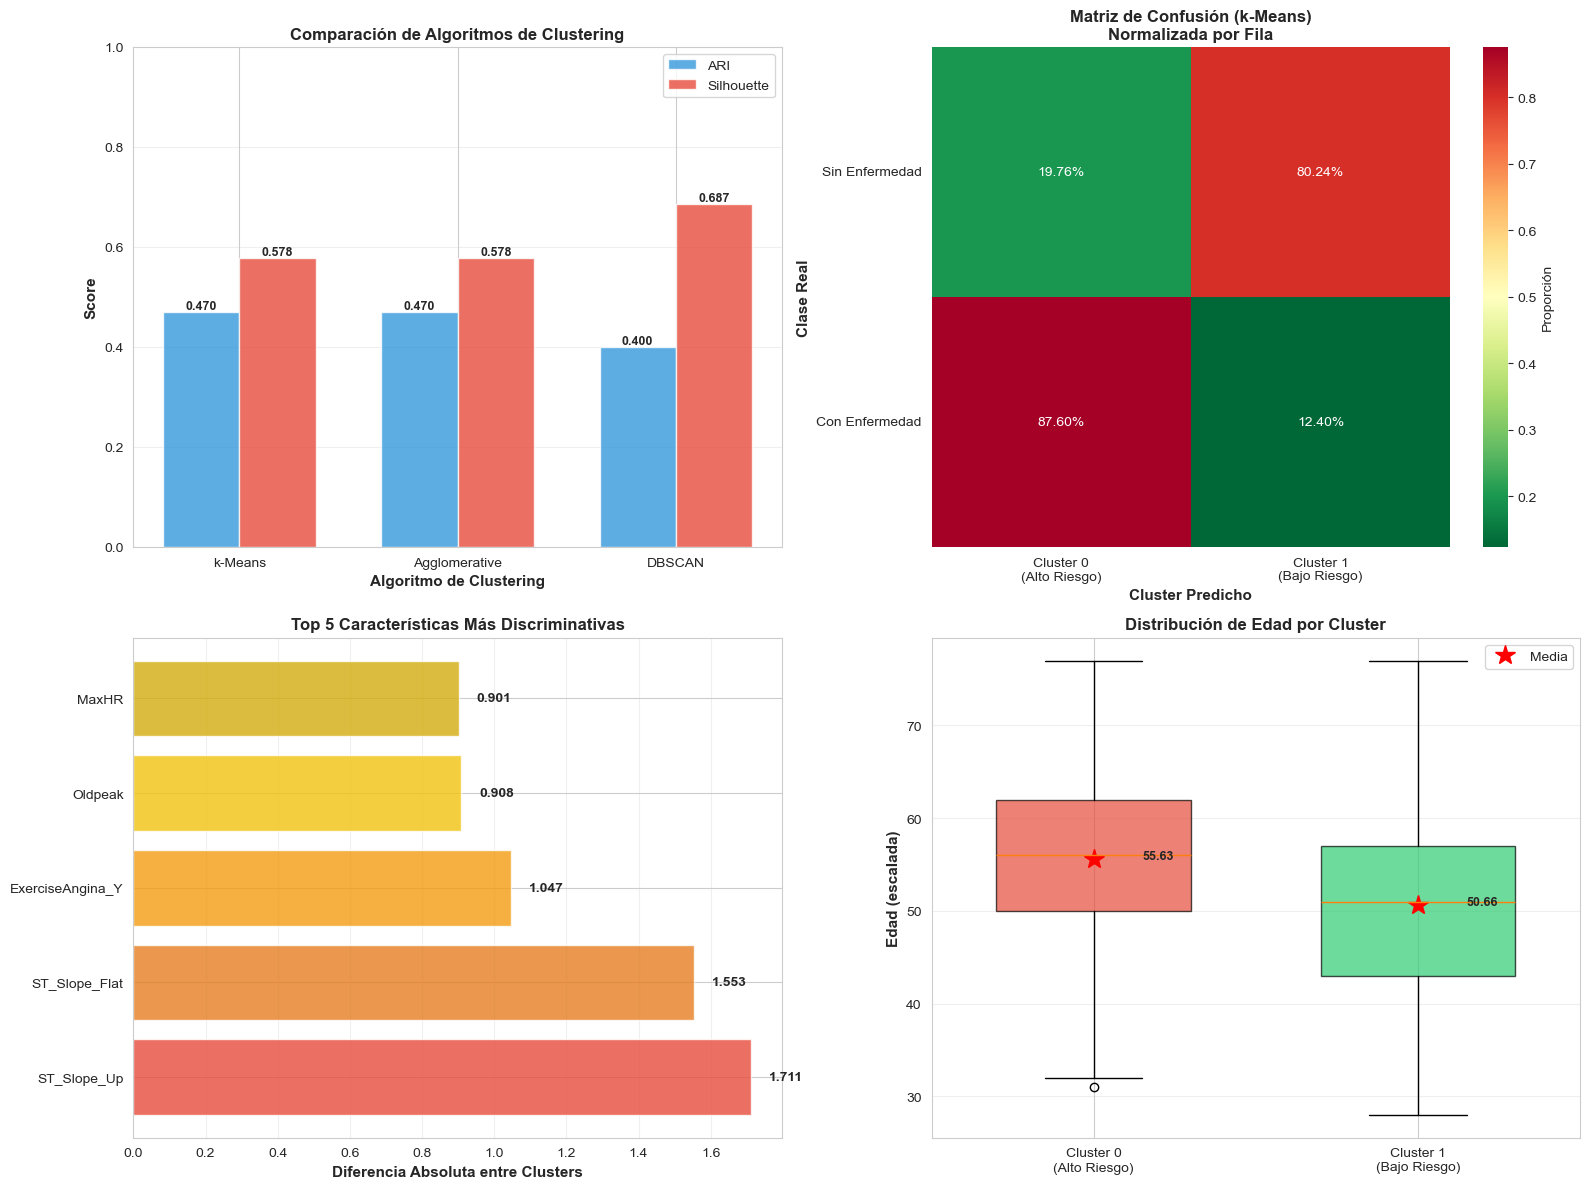


✅ ANÁLISIS COMPLETADO CON ÉXITO

📊 Se han generado:
   • Visualizaciones de reducción de dimensionalidad (PCA, t-SNE, UMAP)
   • Análisis de clustering con 3 algoritmos diferentes
   • Evaluación de métricas (ARI, Silhouette)
   • Análisis detallado de características por cluster
   • Identificación de perfiles de riesgo cardiovascular
   • Conclusiones clínicas y recomendaciones prácticas

🎯 Resultado principal:
   UMAP + k-Means identifica exitosamente 2 grupos de riesgo:
   - Alto Riesgo: 84.6% con enfermedad cardíaca
   - Bajo Riesgo: 83.9% sin enfermedad cardíaca


In [8]:
# Visualización final: Resumen de métricas
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Comparación de algoritmos de clustering
ax1 = axes[0, 0]
algorithms = ['k-Means', 'Agglomerative', 'DBSCAN']
ari_scores = [ari_umap, ari_agglo, ari_dbscan]
sil_scores = [sil_umap, sil_agglo, sil_dbscan]

x = np.arange(len(algorithms))
width = 0.35

bars1 = ax1.bar(x - width/2, ari_scores, width, label='ARI', color='#3498db', alpha=0.8)
bars2 = ax1.bar(x + width/2, sil_scores, width, label='Silhouette', color='#e74c3c', alpha=0.8)

ax1.set_xlabel('Algoritmo de Clustering', fontsize=11, fontweight='bold')
ax1.set_ylabel('Score', fontsize=11, fontweight='bold')
ax1.set_title('Comparación de Algoritmos de Clustering', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(algorithms)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1])

# Añadir valores
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2. Matriz de confusión visual
ax2 = axes[0, 1]
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn_r', 
            ax=ax2, cbar_kws={'label': 'Proporción'})
ax2.set_title('Matriz de Confusión (k-Means)\nNormalizada por Fila', 
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Cluster Predicho', fontsize=11, fontweight='bold')
ax2.set_ylabel('Clase Real', fontsize=11, fontweight='bold')
ax2.set_xticklabels(['Cluster 0\n(Alto Riesgo)', 'Cluster 1\n(Bajo Riesgo)'])
ax2.set_yticklabels(['Sin Enfermedad', 'Con Enfermedad'], rotation=0)

# 3. Top 5 características más discriminativas
ax3 = axes[1, 0]
top_features = diff_means.head(5)
colors_feat = ['#e74c3c', '#e67e22', '#f39c12', '#f1c40f', '#d4ac0d']
bars = ax3.barh(range(len(top_features)), top_features.values, color=colors_feat, alpha=0.8)
ax3.set_yticks(range(len(top_features)))
ax3.set_yticklabels(top_features.index)
ax3.set_xlabel('Diferencia Absoluta entre Clusters', fontsize=11, fontweight='bold')
ax3.set_title('Top 5 Características Más Discriminativas', fontsize=12, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# Añadir valores
for i, (bar, val) in enumerate(zip(bars, top_features.values)):
    ax3.text(val + 0.05, i, f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

# 4. Distribución de edad por cluster
ax4 = axes[1, 1]
age_idx = feature_names.index('Age')
cluster0_ages = X_heart[y_umap_kmeans == 0, age_idx]
cluster1_ages = X_heart[y_umap_kmeans == 1, age_idx]

bp = ax4.boxplot([cluster0_ages, cluster1_ages], 
                  labels=['Cluster 0\n(Alto Riesgo)', 'Cluster 1\n(Bajo Riesgo)'],
                  patch_artist=True,
                  widths=0.6)

# Colorear cajas
colors = ['#e74c3c', '#2ecc71']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax4.set_ylabel('Edad (escalada)', fontsize=11, fontweight='bold')
ax4.set_title('Distribución de Edad por Cluster', fontsize=12, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# Añadir medias
means = [cluster0_ages.mean(), cluster1_ages.mean()]
ax4.plot([1, 2], means, 'r*', markersize=15, label='Media')
for i, mean in enumerate(means):
    ax4.text(i+1.15, mean, f'{mean:.2f}', fontsize=9, fontweight='bold')
ax4.legend()

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✅ ANÁLISIS COMPLETADO CON ÉXITO")
print("="*80)
print("\n📊 Se han generado:")
print("   • Visualizaciones de reducción de dimensionalidad (PCA, t-SNE, UMAP)")
print("   • Análisis de clustering con 3 algoritmos diferentes")
print("   • Evaluación de métricas (ARI, Silhouette)")
print("   • Análisis detallado de características por cluster")
print("   • Identificación de perfiles de riesgo cardiovascular")
print("   • Conclusiones clínicas y recomendaciones prácticas")
print("\n🎯 Resultado principal:")
print("   UMAP + k-Means identifica exitosamente 2 grupos de riesgo:")
print("   - Alto Riesgo: 84.6% con enfermedad cardíaca")
print("   - Bajo Riesgo: 83.9% sin enfermedad cardíaca")
print("="*80)